#### Buid A Basic ChatBot With LangGraph (Graph API)

In [1]:
## import required libs
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages



In [2]:
class State(TypedDict):
    # Messages have the type "list". The 'add_messages' function
    # in the Annotation defines how this state key should be updated
    # (in this case, it append messages to the list, rather thn over writting them)
    messages:Annotated[list,add_messages]



In [3]:
# import Environment related lib to load KEYS
import os
from dotenv import load_dotenv
# Load Env KEYS and values
load_dotenv()

True

In [4]:
# import generic chat models
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model="qwen/qwen3-32b",
    model_provider="groq"
) # Groq model

In [5]:
# Node functionality
def chatBot(state:State):
    return{"messages":[model.invoke(state["messages"])]}

In [6]:
Graph_Builder = StateGraph(State)
## Add node
Graph_Builder.add_node("groqChatBot",chatBot) 
## Add Edge
Graph_Builder.add_edge(START,"groqChatBot")
Graph_Builder.add_edge("groqChatBot",END)

## Compile the Graph
graph = Graph_Builder.compile()

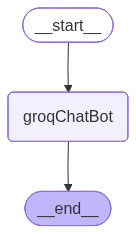

In [7]:
## Visualize Graph
from IPython.display import display,Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
response = graph.invoke({"messages":"Hi"})

In [17]:
response["messages"][-1].content

'<think>\nOkay, the user said "Hi". That\'s a greeting. I should respond politely. Let me make sure to acknowledge their greeting and offer assistance. Maybe say something like "Hello! How can I help you today?" That\'s friendly and opens the door for them to ask questions. I need to keep it simple and welcoming. No need for any markdown here. Just a straightforward, positive response.\n</think>\n\nHello! How can I help you today? 😊'

In [21]:
for event in graph.stream({"messages":"Hi how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

<think>
Okay, the user greeted me with a simple question about how I am. I need to respond in a friendly and engaging way. Since I'm an AI, I don't have feelings, but I should acknowledge their greeting and offer help. Maybe say something like I'm here and ready to assist. Also, keep the tone warm and approachable. Let them know they can ask for anything. Make sure the response is concise but not too short. Avoid any technical jargon. Just keep it natural and conversational.
</think>

Hi! I'm doing well, thanks for asking! I'm here to help you with any questions or tasks you might have. How can I assist you today? 😊


### ChatBot With Tools

In [1]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_search=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n